# Лабораторная работа 8. Обучение GAN


### Работу выполнил:<span style="color:blue"> {Фамилия Имя}</span>

### Сделанную лабораторную работу отправляйте через [ФОРМУ](https://vyatsu-my.sharepoint.com/:f:/g/personal/usr09019_vyatsu_ru/EnlWxp5U5ltDnKRLrXxhnEABn2aLsFNyW5RthdFcoBXNgA)

### Лабораторная работа подготовлена по материалам "Sberbank Summer School. Трек Data Science"

### Как работают GAN

Идея GAN довольно проста. Предположим, мы пытаемся обучать сеть (назовем ее *сеть 1*), которая умеет создавать новые объекты из шума. Когда мы имеем подобную сеть, возникает вопрос: как наша сеть поймет, что она создала хорошие картинки, которые похожи на реальные?

Есть несколько способов решить эту проблему. Например, сравнивать распределения между объектами, генерируемыми сетями, и объектами из реальной природы. Однако можно решить данную проблему сильно проще: давайте кто-то будет сравнивать сгенерированные объекты с настоящими. И этим «кто-то» может быть вторая нейронная сеть (*сеть 2*), решающая задачу классификации, настоящий перед ней объект или искусственно сгенерированный. Первая сеть обычно называется <span style="color:blue">**генератор** </span>, а вторая <span style="color:red">**дискриминатор**</span>.

Соответственно, наша **GAN**-модель — это сочетание **2 нейронных сетей**, <span style="color:blue">**генератора** </span> и <span style="color:red">**дискриминатора**</span>, которые соревнуются и пытаются обойти друг друга, создавая все более реалистичные изображения.


![Alt text](https://www.nonteek.com/wp-content/uploads/2018/01/GAN_en.png "Пример адверсальной атаки")
*источник*: https://www.nonteek.com/en/machine-learning-gans/


### GAN на практике



#### Инициализация среды

Для работы в данном ноутбуке будем пользоваться библиотеками [PyTorch](https://pytorch.org/) и [TorchVision](https://pytorch.org/vision/stable/index.html) в качестве инструмента работы с нейронными сетями.

Импортируем необходимые модули.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

import torch
import torch.nn as nn
import torch.optim

import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils

Зафиксируем random seed, чтобы сделать эксперименты воспроизводимыми.

In [2]:
manualSeed = 42
random.seed(manualSeed)
torch.manual_seed(manualSeed)
print("Random Seed: ", manualSeed)

Random Seed:  42


Для более быстрого обучения нейронных сетей в `PyTorch` можно использовать видеокарту, поддерживающую технологию CUDA.

Если вы работаете в Google Colab, не забудьте выбрать **среду выполнения GPU**.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#### Подготовка данных

В качестве датасета возьмём датасет [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist). Датасет представляет собой черно-белые картинки размером 28 x 28 пикселей с изображением элементов одежды. Всего в датасете 10 классов.

Создадим классы Dataset и Dataloader для тренировочной и тестовой части нашего датасета.

In [4]:
batch_size = 128
image_size = 32

transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5), (0.5)),
                           ])

dataset = torchvision.datasets.FashionMNIST(root='FashionMNIST', train=True,
                                        download=True, transform=transform)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=2)

Посмотрим, как выглядит датасет.

In [5]:
def grid_visual(batch, n_pictures=64, label=''):
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title(label)

    pictures = batch[0].to(device)[:n_pictures]
    vis_grid = vutils.make_grid(pictures, padding=2, normalize=True).cpu()
    vis_grid = np.transpose(vis_grid,(1,2,0))

    plt.imshow(vis_grid)

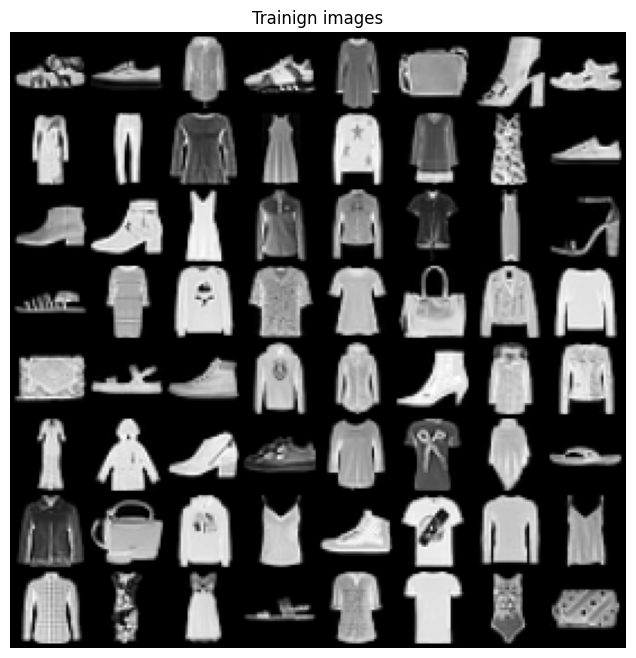

In [6]:


real_batch = next(iter(dataloader))
grid_visual(real_batch, n_pictures=64, label='Trainign images')

## Обучение модели

### Подробнее про модели

Модель <span style="color:blue">**генератора** </span> будем обозначать через G(z), где z — латентный вектор, из которого происходит генерация. В нашем примере будем брать случайный шум в качестве этого вектора. Генератор принимает на вход латентный вектор и создает из него картинку. Соответственно, на выходе у генератора будет трехмерный тензор (многомерная матрица), в котором размерности — длина изображения, ширина изображения и количество каналов (если хотим сделать картинку цветной, нам надо сгенерировать 3 канала для красного, зеленого и синего цветов).

Модель <span style="color:red">**дискриминатора** </span> будем обозначать через D(x). Данная модель принимает на вход картинку (все еще трехмерный тензор) и решает задачу бинарной классификации: определяет, является ли наша картинка настоящей или сгенерированной. Сгенерированные картинки мы будем обозначать через класс 0, настоящие — через класс 1.

### Определим параметры реализации генератора и дискриминатора

Создадим модели генератора и дискриминатора. В качестве моделей мы будем использовать CNN-модели. Генератор и дискриминатор будут представлять из себя симметричные сетки с 4 блоками, состоящими из слоя convolution, слоя batch-normalization и функции активации.

В качестве латентного вектора мы будем использовать вектор случайного шума размерностью 100.

In [7]:
class Generator(nn.Module):
    def __init__(self, latent_size=128, size=64):
        super(Generator, self).__init__()

        self.seq = nn.Sequential(

            nn.ConvTranspose2d( latent_size, size * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(size * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d( size * 4, size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(size * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d( size * 2, size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(size),
            nn.ReLU(True),

            nn.ConvTranspose2d( size, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.seq(x)


class Discriminator(nn.Module):
    def __init__(self, size=64):
        super(Discriminator, self).__init__()

        self.main = nn.Sequential(

            nn.Conv2d(1, size, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(size, size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(size * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(size * 2, size * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(size * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(size * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

In [8]:
#Инициализируем модель генератора
latent_size = 100
model_gener = Generator(latent_size=latent_size, size=64).to(device)
model_gener

Generator(
  (seq): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

In [9]:
#Инициализируем модель дискриминатора
model_disc = Discriminator(size=64).to(device)
model_disc

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (9): Sigmoid()
  )
)

## Обучение GAN

Рассмотрим, как будем обучать модель GAN. Для этого представим функции потерь для наших моделей.

### Генератор

Функция потерь для нашего **генератора** — бинарная кросс-энтропия от сгенерированных картинок:

$$ Loss_G = - \sum_{i=1}^n (y_i \log(\hat{y_i}) + (1 - y_i) \log(1-\hat{y_i})),  $$
$$ \hat{y_i} = D(G(\mathbf{z}_i)). $$
Здесь $y_i$ — класс объекта для дискриминатора. У сгенерированных фейковых картинок метка 0, у настоящих — 1, $\mathbf{z}_i$ — исходный латентный вектор для генерации изображения $i$, в нашем эксперименте мы будем обозначать его как случайный шум.

Однако поскольку наш генератор создает только ненастоящие картинки с классом $0$, то можно упростить функцию потерь:

$$
Loss_G = -\sum_{i=1}^n \log (1 - D(G(\mathbf{z}_i))).
$$

### Дискриминатор

Функция потерь модели **дискриминатора** — тоже бинарная кросс-энтропия:

$$
Loss_G = - \sum_{i=1}^n (y_i \log(\hat{D(\mathbf{x})}) + (1-y_i) \log(1 - \hat{D(\mathbf{x})})).  
$$
Здесь $y_i$ — истинный класс объекта (у нас 0 — фейковые картинки, 1 — настоящие), $\mathbf{x}$ — картинка, подаваемая на вход модели. Давайте немного преобразуем нашу функцию потерь.

Но в случае дискриминатора картинки могут быть как реальные, так и полученные от дискриминатора.

### Обучение

Модели мы будем обучать по очереди: сначала модель дискриминатора, потом генератор. Причина этого очень проста: если наш дискриминатор ни на что не способен, генератор не поймет, сделал он что-то стоящее или нет.

Одной итерацией будем называть:
1. прогон данных через дискриминатор и оптимизацию параметров
2. прогон данных через генератор и обучение генератора

### Реализация

В качестве функции потерь будем использовать бинарную кросс-энтропию. В качестве optimizer возьмем Adam.

In [10]:
num_epochs = 1
lr = 0.0002

# создаем фиксированный вектор шума, из которого будем генерировать картинки
fixed_noise = torch.randn(64, latent_size, 1, 1, device=device)

criterion = nn.BCELoss()

optimizer_disc = torch.optim.Adam(model_disc.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_gener = torch.optim.Adam(model_gener.parameters(), lr=lr, betas=(0.5, 0.999))

Запустим процесс обучения:

In [11]:
img_list = [] # будем складывать картинки, чтобы потом посмотреть, как учился наш GAN
gener_losses = [] # loss Генератора для графика
disc_losses = [] # loss Дискриминатора
iter_ = 0

n_batches = len(dataloader)

for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(dataloader):

        #***************************************
        # Обучаем Дискриминатор
        #***************************************

        model_disc.zero_grad()

        real_images = real_images.to(device)
        BS = real_images.size(0)

        true_labels = torch.ones((BS,), dtype=torch.float, device=device)

        # прогоняем реальные картинки через дискриминатор
        pred_labels = model_disc(real_images).view(-1)
        loss_disc_real = criterion(pred_labels, true_labels)
        loss_disc_real.backward()

        # прогоняем сгенерированные картинки

        # генерим картинки
        noise = torch.randn(BS, latent_size, 1, 1, device=device)
        fake_images = model_gener(noise)
        true_labels = torch.zeros((BS,), dtype=torch.float, device=device)

        # прогоняем сгенерированные картинки через дискриминатор
        pred_labels = model_disc(fake_images.detach()).view(-1)
        loss_disc_fake = criterion(pred_labels, true_labels)
        loss_disc_fake.backward()

        # обучаем дискриминатор
        loss_disc = 0.5*(loss_disc_real + loss_disc_fake)
        optimizer_disc.step()


        #***************************************
        # Обучаем Генератор
        #***************************************

        model_gener.zero_grad()

        #Прогоняем сгенерированные картинки через дискриминатор, чтобы обучить генератор
        true_labels = torch.ones((BS,), dtype=torch.float, device=device)
        pred_labels = model_disc(fake_images).view(-1)

        # обучаем Генератор
        loss_gener = criterion(pred_labels, true_labels)
        loss_gener.backward()
        optimizer_gener.step()


        # выводим результаты
        if i % 50 == 0:
            gener_losses.append(loss_gener.item())
            disc_losses.append(loss_disc.item())
            print(f'ep {epoch}; batch {i}/{n_batches}\t Loss D: {loss_disc.item()}\tLoss G: {loss_gener.item()}')


        if (iter_ % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake_images = model_gener(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake_images, padding=2, normalize=True))

        iter_ += 1

ep 0; batch 0/469	 Loss D: 0.7468917965888977	Loss G: 1.2095677852630615
ep 0; batch 50/469	 Loss D: 0.012621058151125908	Loss G: 5.365765571594238
ep 0; batch 100/469	 Loss D: 0.004082684870809317	Loss G: 5.8630805015563965
ep 0; batch 150/469	 Loss D: 0.002529505640268326	Loss G: 6.786668300628662
ep 0; batch 200/469	 Loss D: 0.5601006150245667	Loss G: 1.6394550800323486
ep 0; batch 250/469	 Loss D: 0.36157625913619995	Loss G: 1.7283368110656738
ep 0; batch 300/469	 Loss D: 0.6772325038909912	Loss G: 4.397563934326172
ep 0; batch 350/469	 Loss D: 0.23696346580982208	Loss G: 1.9522850513458252
ep 0; batch 400/469	 Loss D: 0.26288527250289917	Loss G: 1.8503670692443848
ep 0; batch 450/469	 Loss D: 0.2719145119190216	Loss G: 1.420358419418335


Выведем наши функции потерь:

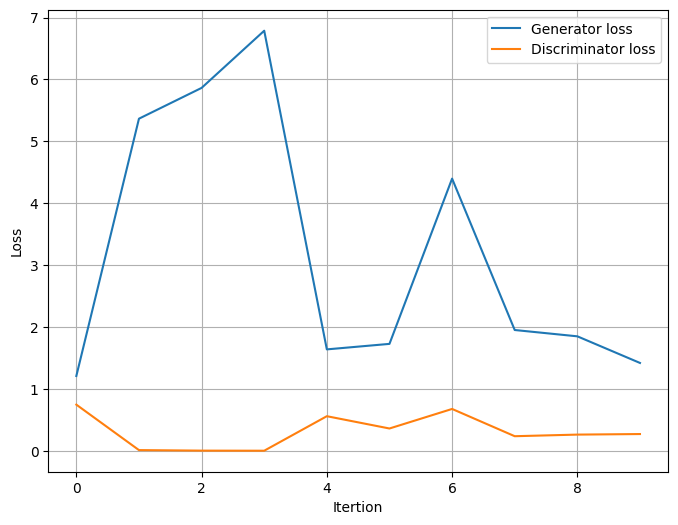

In [12]:
plt.figure(figsize=(8, 6))
plt.plot(gener_losses, label='Generator loss')
plt.plot(disc_losses, label='Discriminator loss')
plt.legend()

plt.ylabel('Loss')
plt.xlabel('Itertion')
plt.grid()
plt.show()

К сожалению, по функциям потерь моделей GAN трудно оценить сходимость модели. Обычно понимают, что GAN сошелся, когда обе функции потерь стабилизировались - перестали меняться. Также полезно выводить результаты работы модели во время обучения и сравнивать их с реальными изображениями. Когда качество генерированных картинок перестанет меняться, мы поймем, что модель сошлась.

Отметим, что у нас есть скачки в функциях потерь моделей, особенно это видно по функции потерь дискриминатора. По графику можно заметить, что скачки Discriminator loss происходили, когда падала функция потерь генератора. В эти моменты генератор обучался настолько хорошо, что текущая версия дискриминатор начинала сильно ошибаться. Такие скачки периодически встречаются при обучении GAN. Это нормальный процесс, особенно в начале обучения.

Посмотрим, какие картинки создавались на разных итерациях обучения нашей модели.

In [13]:
def grid_animation(img_list):
    fig = plt.figure(figsize=(8,8))
    plt.axis("off")

    ims = [[plt.imshow(np.transpose(i,(1,2,0)), animated=True)] for i in img_list]
    animate = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)

    HTML(animate.to_jshtml())

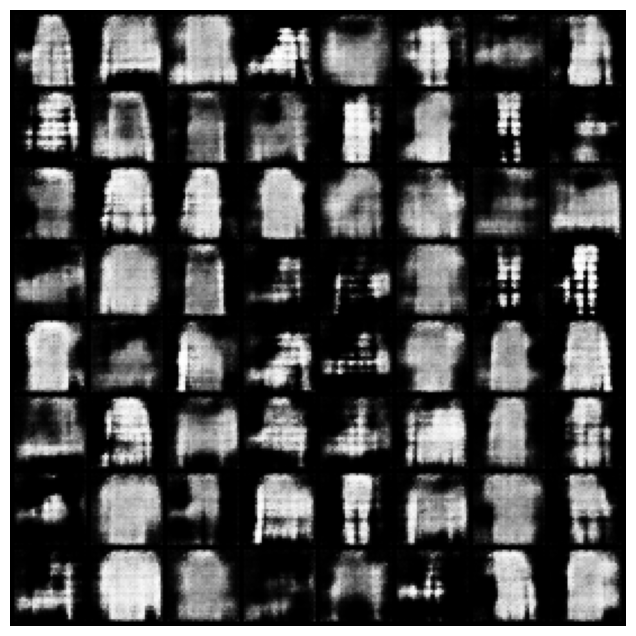

In [14]:
fig = plt.figure(figsize=(8,8))
plt.axis("off")

ims = [[plt.imshow(np.transpose(i,(1,2,0)), animated=True)] for i in img_list]
animate = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)

HTML(animate.to_jshtml())

Сравним чуть ближе настоящие и сгенерированные изображения.

In [15]:
def plot_images(images, label):

    len_batch = len(images)
    plt.figure(figsize=(20, 3))
    plt.title(label)

    for i in range(len(images)):

        plt.subplot(1, len_batch, i+1)
        original_img = images[i] / 2 + 0.5     # unnormalize

        matrix_image = original_img.cpu().detach().numpy()

        if matrix_image.shape[0] == 1:
            image = matrix_image[0]
            matrix_image = np.array([image, image, image])

        plt.imshow(np.transpose(matrix_image, (1, 2, 0)))
        plt.axis('off')

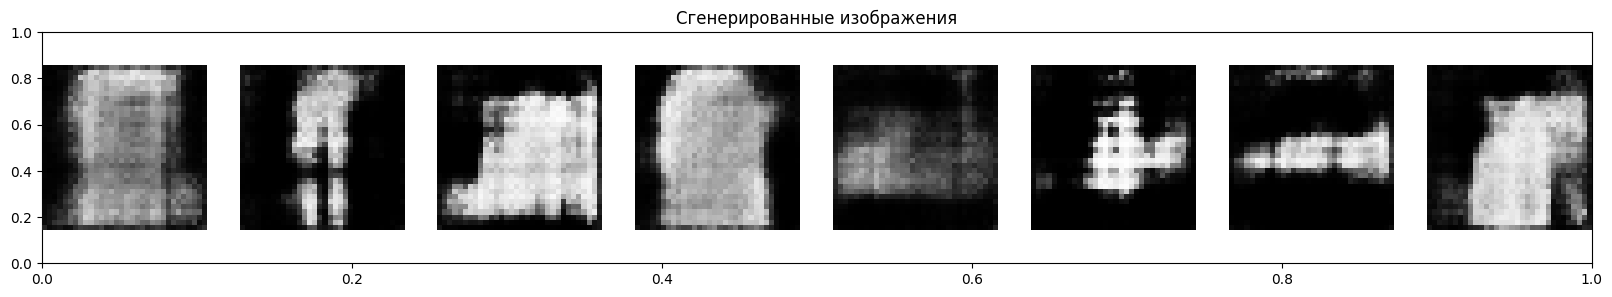

In [16]:
n_images = 8

noise = torch.randn(n_images, latent_size, 1, 1, device=device)
images = model_gener(noise)

plot_images(images, label='Сгенерированные изображения')

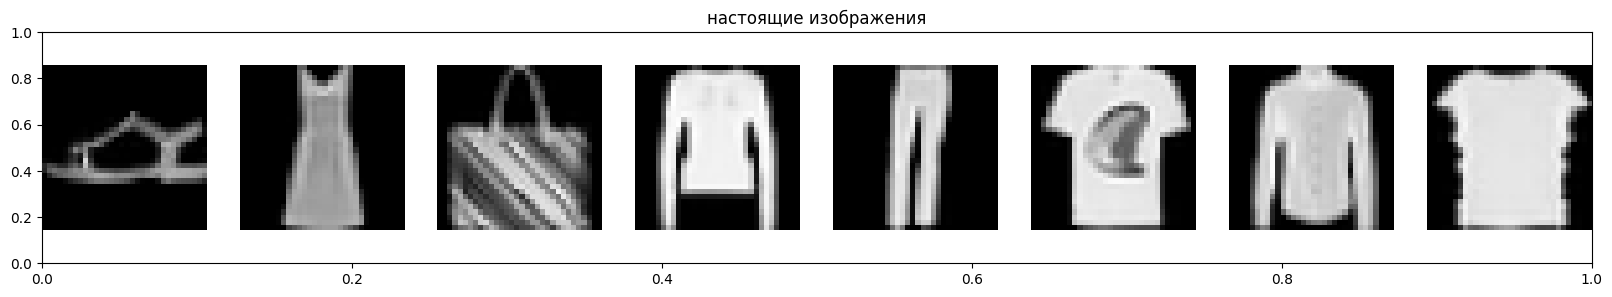

In [17]:
n_images = 8

dataiter = iter(dataloader)
images, _ = next(dataiter)
images_sample = images[:n_images]

plot_images(images_sample, label='настоящие изображения')

Как мы видим, сгенерированные изображения довольно похожи на настоящие, но все еще отличимы. Чтобы получить более высокое качество, можно было бы поэкспериментировать с архитектурой сетей, lr, количеством эпох, другими параметрами нашего эксперимента и другими генеративными моделями.

**Задание 1.** Обучите генерировать кошек GAN (архитектуры из примера выше). <a href="https://www.kaggle.com/spandan2/cats-faces-64x64-for-generative-models">Оригинальный датасет кошек</a>. Обучите на 40 эпохах. Приведите примеры генерируемых изображений.

In [18]:
from torchvision.datasets import ImageFolder

DATA_DIR = "../data/cats"
image_size = 64
batch_size = 128
stats = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
dataset_cats = ImageFolder(DATA_DIR, transform=transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(*stats)])
)
dataloader_cats = torch.utils.data.DataLoader(dataset_cats, batch_size, shuffle=True, num_workers=0, pin_memory=True)

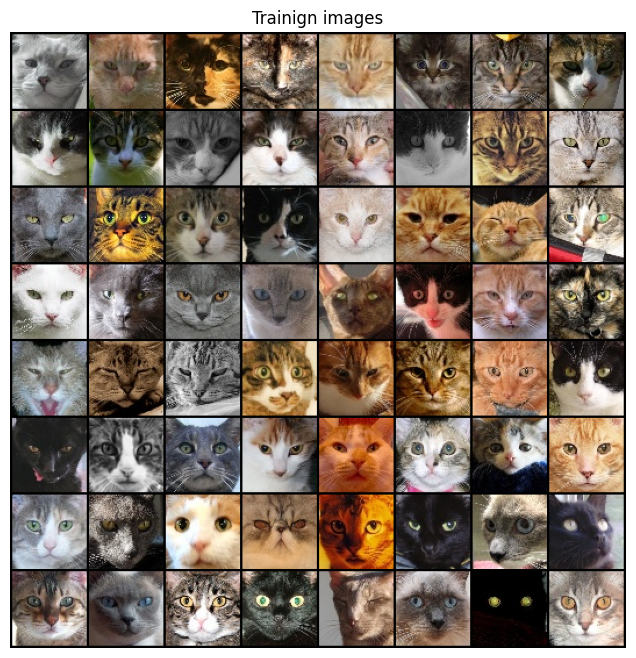

In [19]:
real_batch = next(iter(dataloader_cats))
grid_visual(real_batch, n_pictures=64, label='Trainign images')

Epoch [0/100] Batch 0/124 Loss D: 0.6893 Loss G: 3.1699
Epoch [0/100] Batch 50/124 Loss D: 0.3011 Loss G: 9.7675
Epoch [0/100] Batch 100/124 Loss D: 0.3079 Loss G: 3.0885
Epoch [1/100] Batch 0/124 Loss D: 0.1551 Loss G: 5.5046
Epoch [1/100] Batch 50/124 Loss D: 0.4315 Loss G: 3.7319
Epoch [1/100] Batch 100/124 Loss D: 1.2459 Loss G: 2.5492
Epoch [2/100] Batch 0/124 Loss D: 0.3027 Loss G: 2.7530
Epoch [2/100] Batch 50/124 Loss D: 0.3584 Loss G: 2.2700
Epoch [2/100] Batch 100/124 Loss D: 0.3779 Loss G: 3.8674
Epoch [3/100] Batch 0/124 Loss D: 0.2451 Loss G: 3.6965
Epoch [3/100] Batch 50/124 Loss D: 0.3945 Loss G: 4.8785
Epoch [3/100] Batch 100/124 Loss D: 0.4824 Loss G: 5.1775
Epoch [4/100] Batch 0/124 Loss D: 0.4620 Loss G: 2.4820
Epoch [4/100] Batch 50/124 Loss D: 0.5405 Loss G: 4.9726
Epoch [4/100] Batch 100/124 Loss D: 0.2496 Loss G: 4.5943
Epoch [5/100] Batch 0/124 Loss D: 0.4024 Loss G: 4.6304
Epoch [5/100] Batch 50/124 Loss D: 0.8092 Loss G: 4.8477
Epoch [5/100] Batch 100/124 Loss

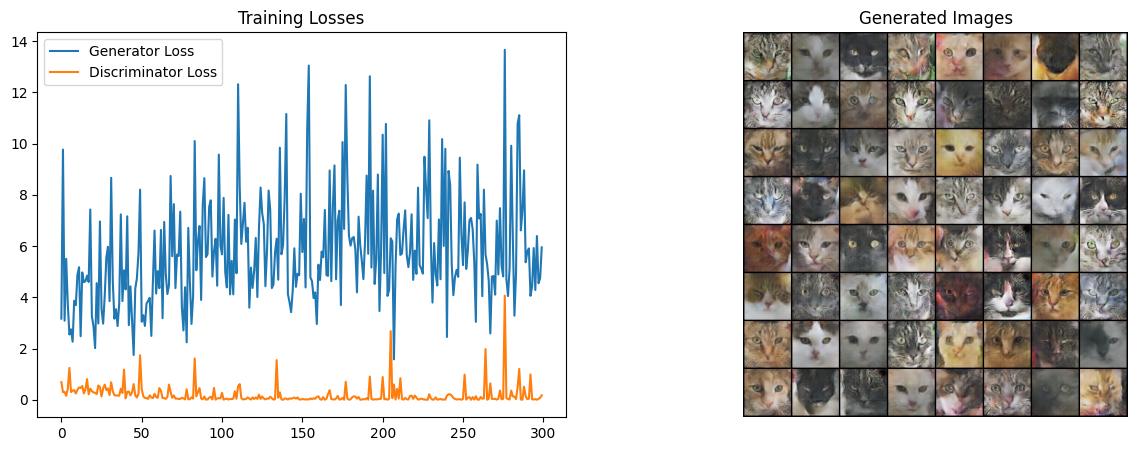

In [20]:
# Параметры
batch_size = 128
image_size = 64
latent_size = 100
num_epochs = 100
lr = 0.0002

class GeneratorCats(nn.Module):
    def __init__(self, latent_size=100, size=64):
        super(GeneratorCats, self).__init__()
        self.seq = nn.Sequential(
            nn.ConvTranspose2d(latent_size, size*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(size*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(size*8, size*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(size*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(size*4, size*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(size*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(size*2, size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(size),
            nn.ReLU(True),

            nn.ConvTranspose2d(size, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.seq(x)

class DiscriminatorCats(nn.Module):
    def __init__(self, size=64):
        super(DiscriminatorCats, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, size, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(size, size*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(size*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(size*2, size*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(size*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(size*4, size*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(size*8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(size*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_gener = GeneratorCats(latent_size=latent_size, size=64).to(device)
model_disc = DiscriminatorCats(size=64).to(device)

criterion = nn.BCELoss()
optimizer_disc = torch.optim.Adam(model_disc.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_gener = torch.optim.Adam(model_gener.parameters(), lr=lr, betas=(0.5, 0.999))

fixed_noise = torch.randn(64, latent_size, 1, 1, device=device)
img_list = []
gener_losses = []
disc_losses = []

for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(dataloader_cats):
        # Обучение дискриминатора
        model_disc.zero_grad()
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        output = model_disc(real_images).view(-1, 1)
        loss_disc_real = criterion(output, real_labels)

        noise = torch.randn(batch_size, latent_size, 1, 1, device=device)
        fake_images = model_gener(noise)
        fake_labels = torch.zeros(batch_size, 1, device=device)
        output = model_disc(fake_images.detach()).view(-1, 1)
        loss_disc_fake = criterion(output, fake_labels)

        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        loss_disc.backward()
        optimizer_disc.step()

        model_gener.zero_grad()
        output = model_disc(fake_images).view(-1, 1)
        loss_gener = criterion(output, real_labels)
        loss_gener.backward()
        optimizer_gener.step()

        if i % 50 == 0:
            gener_losses.append(loss_gener.item())
            disc_losses.append(loss_disc.item())
            print(f'Epoch [{epoch}/{num_epochs}] Batch {i}/{len(dataloader_cats)} '
                  f'Loss D: {loss_disc.item():.4f} Loss G: {loss_gener.item():.4f}')

    with torch.no_grad():
        fake = model_gener(fixed_noise).detach().cpu()
        img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(gener_losses, label='Generator Loss')
plt.plot(disc_losses, label='Discriminator Loss')
plt.legend()
plt.title('Training Losses')

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Generated Images")
plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))
plt.show()

**Задание 2.** Возьмите классификатор, предобученый на ImageNet. Проверьте с какой точностью классификатор распознает сгенерированные картинки кошек (на 100 картинках). Метки класса для кошек определите с помощью описания классов ImageNet.

РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ СГЕНЕРИРОВАННЫХ КОШЕК
Общая точность распознавания как кошек: 68.00%
Количество изображений, распознанных как кошки: 68/100

Детали по классам:
  persian cat: 22 изображений
  tabby cat: 24 изображений
  siamese cat: 2 изображений
  egyptian cat: 18 изображений
  tiger cat: 2 изображений

Визуализация примеров классификации:


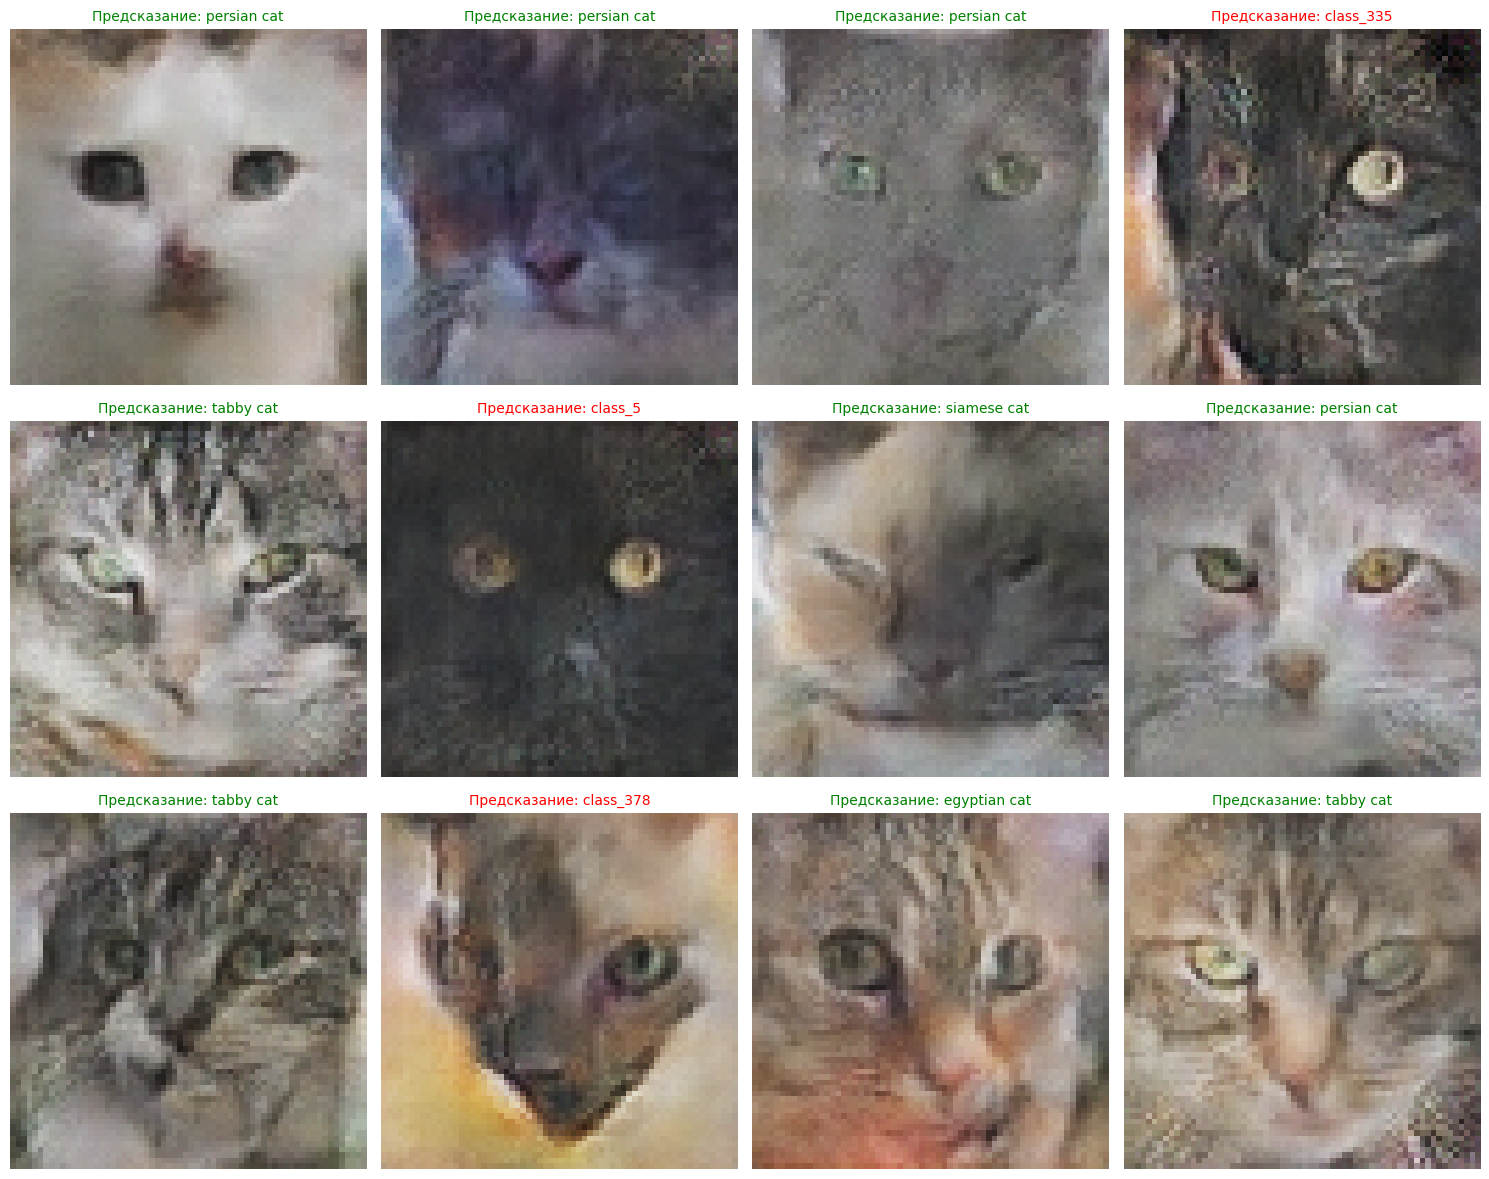

ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА
Топ-5 предсказаний для примеров:

Пример 1:
  1. class_283: 84.29% CAT
  2. class_291: 3.12%
  3. class_286: 2.40%
  4. class_260: 0.88%
  5. class_287: 0.63%

Пример 2:
  1. class_285: 33.84% CAT
  2. class_281: 32.70% CAT
  3. class_287: 7.11%
  4. class_282: 5.04% CAT
  5. class_284: 3.51% CAT

Пример 3:
  1. class_286: 29.42%
  2. class_287: 20.60%
  3. class_283: 17.09% CAT
  4. class_291: 11.20%
  5. class_373: 1.93%


In [21]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import ResNet50_Weights
import numpy as np

model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
model.eval()
model = model.to(device)

cat_classes = [281, 282, 283, 284, 285]

transform_imagenet = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

def evaluate_generated_cats(generator, num_images=100, latent_size=100):
    generator.eval()

    with torch.no_grad():
        noise = torch.randn(num_images, latent_size, 1, 1, device=device)
        generated_images = generator(noise)

    processed_images = []
    for img in generated_images:
        img_denorm = (img + 1) / 2
        img_processed = transform_imagenet(img_denorm)
        processed_images.append(img_processed)

    processed_batch = torch.stack(processed_images)

    with torch.no_grad():
        outputs = model(processed_batch)
        _, predicted = torch.max(outputs, 1)

    cat_predictions = sum(1 for pred in predicted.cpu().numpy() if pred in cat_classes)
    accuracy = cat_predictions / num_images * 100
    class_counts = {}
    for pred in predicted.cpu().numpy():
        if pred in cat_classes:
            class_name = get_imagenet_class_name(pred)
            class_counts[class_name] = class_counts.get(class_name, 0) + 1

    return accuracy, class_counts, generated_images, predicted

def get_imagenet_class_name(class_id):
    cat_names = {
        281: "tabby cat",
        282: "tiger cat",
        283: "persian cat",
        284: "siamese cat",
        285: "egyptian cat"
    }
    return cat_names.get(class_id, f"class_{class_id}")

accuracy, class_counts, generated_imgs, predictions = evaluate_generated_cats(model_gener, num_images=100)

print("РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ СГЕНЕРИРОВАННЫХ КОШЕК")
print(f"Общая точность распознавания как кошек: {accuracy:.2f}%")
print(f"Количество изображений, распознанных как кошки: {sum(class_counts.values())}/100")
print("\nДетали по классам:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count} изображений")

def show_classification_examples(images, predictions, num_examples=12):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(3, 4, figsize=(15, 12))
    axes = axes.ravel()

    for i in range(num_examples):
        img = images[i].cpu() / 2 + 0.5
        pred_class = predictions[i].item()

        is_cat = pred_class in cat_classes
        class_name = get_imagenet_class_name(pred_class) if is_cat else f"class_{pred_class}"
        color = 'green' if is_cat else 'red'

        axes[i].imshow(np.transpose(img, (1, 2, 0)))
        axes[i].set_title(f"Предсказание: {class_name}", color=color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("\nВизуализация примеров классификации:")
show_classification_examples(generated_imgs[:12], predictions[:12])

print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА")

def show_top_predictions(generator, num_examples=5):
    generator.eval()

    with torch.no_grad():
        noise = torch.randn(num_examples, latent_size, 1, 1, device=device)
        images = generator(noise)
        processed_imgs = []
        for img in images:
            img_denorm = (img + 1) / 2
            img_processed = transform_imagenet(img_denorm)
            processed_imgs.append(img_processed)

        processed_batch = torch.stack(processed_imgs)
        outputs = model(processed_batch)
        probabilities = torch.softmax(outputs, dim=1)
        top5_probs, top5_classes = torch.topk(probabilities, 5, dim=1)

    try:
        import requests
        import json
        url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
        response = requests.get(url)
        imagenet_labels = json.loads(response.text)
    except:
        imagenet_labels = {str(i): f"class_{i}" for i in range(1000)}

    print("Топ-5 предсказаний для примеров:")
    for i in range(num_examples):
        print(f"\nПример {i+1}:")
        for j in range(5):
            class_id = top5_classes[i][j].item()
            prob = top5_probs[i][j].item() * 100
            class_name = imagenet_labels[str(class_id)] if str(class_id) in imagenet_labels else f"class_{class_id}"
            marker = " CAT" if class_id in cat_classes else ""
            print(f"  {j+1}. {class_name}: {prob:.2f}%{marker}")

show_top_predictions(model_gener, 3)